# Bonus Questions for More In-Depth OpenMP

In this notebook we will explore some more advanced OpenMP concepts. Not all of these are critical for speeding up weather and climate codes, so they are collected in this bonus notebook.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "72"
os.environ["OMP_PROC_BIND"] = "close"
os.environ["OMP_PLACES"] = "cores"

## Parallel Execution Time

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B1: Assume you have a program that is 99% parallelizable. Parallelization also adds overhead to the code, for example due to communication or synchronization. The overhead is $0.001 \cdot \log(n)$, where $n$ is the number of cores. Write a simple experiment to find the number of cores that minimizes the runtime.
</div>

In [2]:
import numpy as np
import math

# TODO: choose the search interval and runtime model
cores = range(1, 10000)
run_time = [0.01 + 0.99 / float(x) + 0.001 * math.log(x) for x in cores]
index_min = np.argmin(run_time)
print(cores[index_min])


990


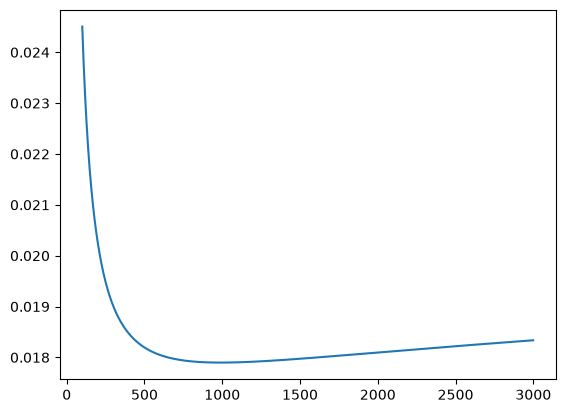

In [3]:
import matplotlib.pyplot as plt

# TODO: plot the runtime model
cores = range(100, 3000)
run_time = [0.01 + 0.99 / float(x) + 0.001 * math.log(x) for x in cores]
plt.plot(cores, run_time)

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B2: Can we mathematically prove that this is actually the ideal number of cores?
    </div>

$\frac{d}{dn}(0.01+\frac{0.99}{n} + 0.001\log(n)) = 0$

$\frac{0.001n - 0.99}{n^2} = 0$

$n = 990$

## Amdahl's Law

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B3: Assume you have a program that is 99% parallelizable. If you have three machines available - your laptop with 8 cores, all the fat nodes of Brutus with 3840 cores, and the Alps system with its 774'144 CPU cores - how much speedup do these machines offer you?
</div>

In [4]:
# TODO: apply Amdahl's law for each core count
cores = [1, 8, 3840, 774144]
run_time = [0.01 + 0.99 / x for x in cores]
speedup = [run_time[0] / x for x in run_time]
print(speedup)

[1.0, 7.4766355140186915, 97.48667174409749, 99.98721331674938]


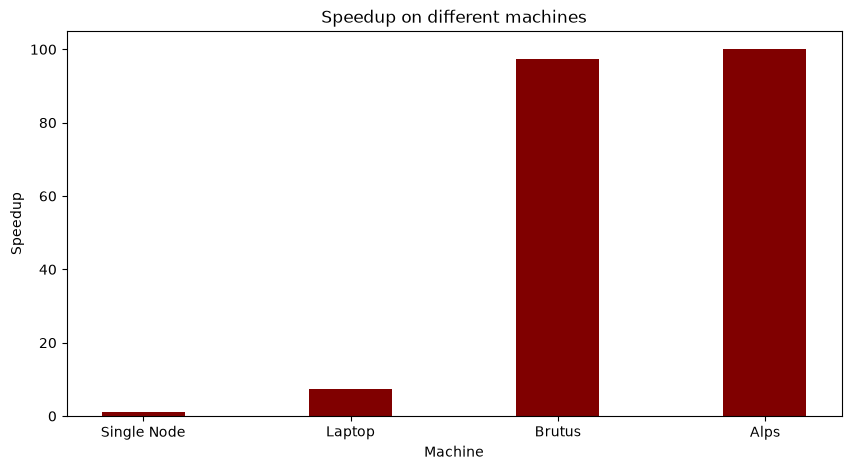

In [5]:
import matplotlib.pyplot as plt

# creating the dataset
system = ["Single Node", "Laptop", "Brutus", "Alps"]
fig = plt.figure(figsize=(10, 5))
 
# creating the bar plot
plt.bar(system, speedup, color='maroon', width=0.4)
 
plt.xlabel("Machine")
plt.ylabel("Speedup")
plt.title("Speedup on different machines")
plt.show()

# Exploration of Math and Synchronization Overheads

In this section we explore the difference in speed between expensive math operations and different synchronization mechanisms.

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B4: Write a program <tt>expensive.cpp</tt> where we loop over $n$ iterations and take the <code>acos</code> of the <code>cos</code> of the <code>asin</code> of the <code>sin</code> of the absolute value of the iteration number divided by the total number of iterations.

</div>
We sum all these values and verify correctness by printing the result.
Ideally, the program is parameterized by the number of iterations and the number of threads used.


In [6]:
%%bash
make clean

rm -f -rf *~ *.o *.mod *.MOD *.i core.* *.out *.lst *.x *.x+orig *.x+[0-9]* *.dat *.report result_*.py report*.txt perf/* out*.txt


In [7]:
%%bash
mpic++ expensive.cpp -fopenmp -o expensive.x -O3

In [8]:
%%bash
srun -n 1 ./expensive.x 10000001 2

5e+06
0.301667


The output value should be 5e+06

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B4a: Make sure to add a timer around your code.
</div>

In [9]:
%%bash
mpic++ expensive.cpp -fopenmp -o expensive.x -O3

In [10]:
%%bash
srun -n 1 ./expensive.x 10000001 12

5e+06
0.301466


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B5: Duplicate the file into a file called <tt>critical.cpp</tt>. Parallelize the for loop and protect the update to the shared sum with a critical section.
How much speedup do we get?
</div>    

In [11]:
%%bash
mpic++ critical.cpp -fopenmp -o critical.x -O3

In [12]:
%%bash
srun -n 1 ./critical.x 10000001 12

5e+06
4.97662


<b>Answer</b><br>
This indicates a slowdown rather than a speedup. The reason is that critical sections introduce significant synchronization overhead. Each thread must wait to enter the critical section, which serializes the protected work and negates the benefits of parallelization.

<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B6: Duplicate the file into a file called <tt>atomic.cpp</tt> and update the critical section to use an atomic update instead.
How much speedup do we get?
</div>    

In [13]:
%%bash
mpic++ atomic.cpp -fopenmp -o atomic.x -O3

In [14]:
%%bash
srun -n 1 ./atomic.x 10000001 12

5e+06
0.350034


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B7: Duplicate the file into a file called <tt>reduction.cpp</tt> and change the loop to use an OpenMP reduction clause. How do the timings compare between the reduction and the atomic update?
</div>

In [15]:
%%bash
mpic++ reduction.cpp -fopenmp -o reduction.x -O3

In [16]:
%%bash
srun -n 1 ./reduction.x  10000001 12

5e+06
0.0286837


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B8: Lastly, try to separate the expensive computation from the summation in <tt>fully_parallel.cpp</tt>: first compute all local values in parallel, then sum those values in a second parallel reduction loop. How does that compare to the above timings?
</div>

In [17]:
%%bash
mpic++ fully_parallel.cpp -fopenmp -o fully_parallel.x -O3

In [18]:
%%bash
srun -n 1 ./fully_parallel.x 10000001 12

5e+06
0.0327536


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
So far, we had a very expensive computation instead of a simple one. Copy <tt>fully_parallel.cpp</tt> into <tt>iterations_count_fully_parallel.cpp</tt> and <tt>atomic.cpp</tt> into <tt>iterations_count_atomic.cpp</tt>.<br>
In the new versions, change the computation to just use the iteration index.<br>
<b>B9:</b> How do the two versions compare to each other? How do they compare to their expensive counterparts?
</div>

In [19]:
%%bash
mpic++ iterations_count_atomic.cpp -fopenmp -o iterations_count_atomic.x -O3
mpic++ iterations_count_fully_parallel.cpp -fopenmp -o iterations_count_fully_parallel.x -O3


In [20]:
%%bash
srun -n 1 ./iterations_count_atomic.x 10000001 12

5e+13
0.219701


In [21]:
%%bash
srun -n 1 ./iterations_count_fully_parallel.x 10000001 12

5e+13
0.00450411


# Exploration of Caching
<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B10: Parallelize <tt>fully_parallel.cpp</tt> in a new file <tt>static_small_expensive.cpp</tt> with a static loop schedule of size 1. Slightly change the output to be 
<br><code>output[i] = acos(cos(asin(sin(abs(input[i]))))) + output[i];</code>
</div>


In [22]:
%%bash
mpic++ static_small_expensive.cpp -fopenmp -o static_small_expensive.x -O3

In [23]:
%%bash
srun -n 1 ./static_small_expensive.x 10000001 12

5e+06
0.0299359


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B11: How does the runtime change if we move to a static schedule of size 80? Copy <tt>static_small_expensive.cpp</tt> and use a different scheduling policy in <tt>static_large_expensive.cpp</tt>.
</div>


In [24]:
%%bash
mpic++ static_large_expensive.cpp -fopenmp -o static_large_expensive.x -O3

In [25]:
%%bash
srun -n 1 ./static_large_expensive.x 10000001 12

5e+06
0.0302709


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
B12: How do these two results change if we move to a cheap iteration that only adds the iteration number? <br><code>output[i] = i + output[i];</code> <br>Explore this in <tt>static_small_cheap.cpp</tt> and <tt>static_large_cheap.cpp</tt>.
</div>



In [26]:
%%bash
mpic++ static_small_cheap.cpp -fopenmp -o static_small_cheap.x -O3
mpic++ static_large_cheap.cpp -fopenmp -o static_large_cheap.x -O3


In [27]:
%%bash
srun -n 1 ./static_small_cheap.x 10000001 12

5e+13
0.0112088


In [28]:
%%bash
srun -n 1 ./static_large_cheap.x 10000001 12

5e+13
0.00460993


In [29]:
%%bash
make clean

rm -f -rf *~ *.o *.mod *.MOD *.i core.* *.out *.lst *.x *.x+orig *.x+[0-9]* *.dat *.report result_*.py report*.txt perf/* out*.txt
